<a href="https://colab.research.google.com/github/Shoukat-Ali123/Machine-Learning-01/blob/main/Medical_Cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [2]:
df=pd.read_csv('/content/insurance (2).csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

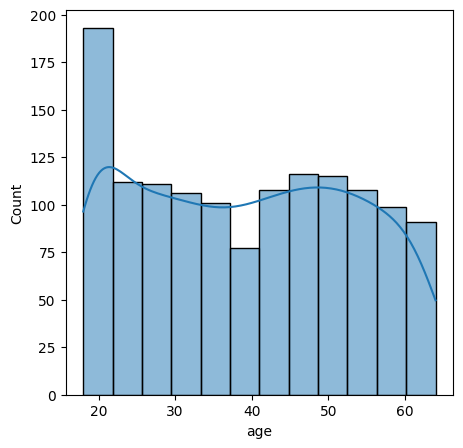

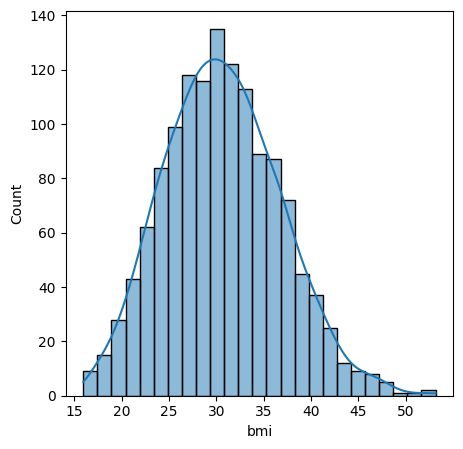

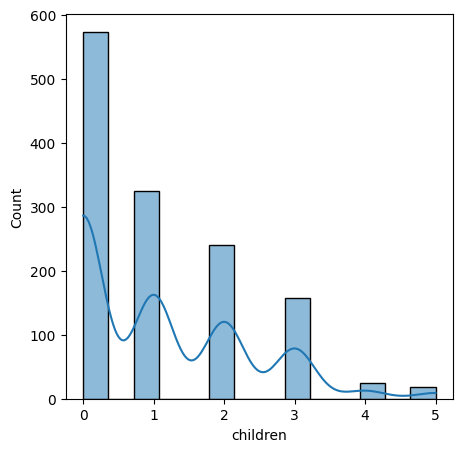

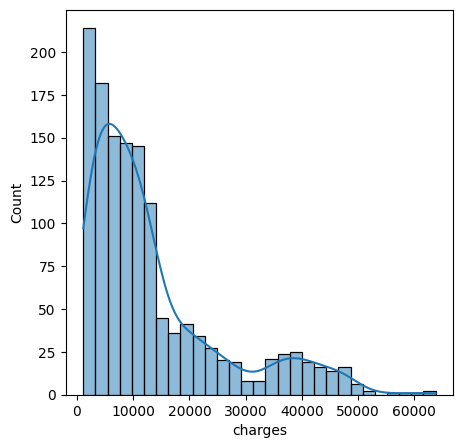

In [12]:
numeric_cols=['age', 'bmi', 'children', 'charges']
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.show()

<Axes: xlabel='sex', ylabel='count'>

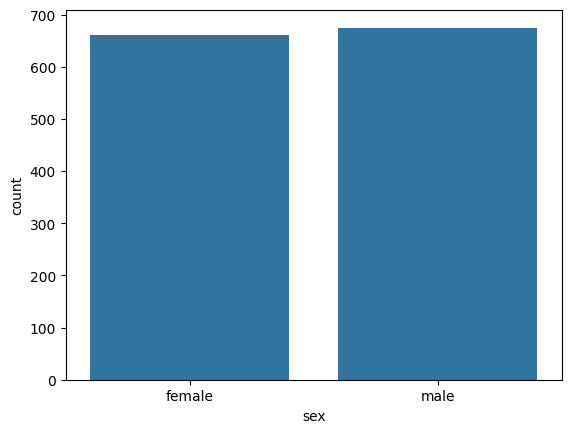

In [14]:
sns.countplot(x=df['sex'])

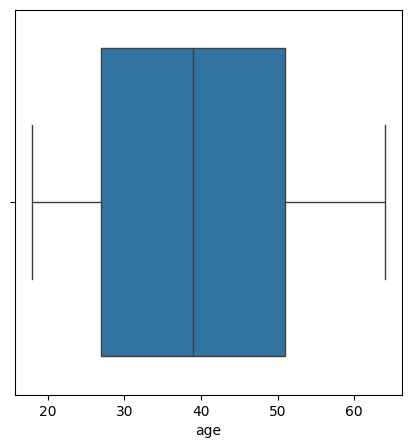

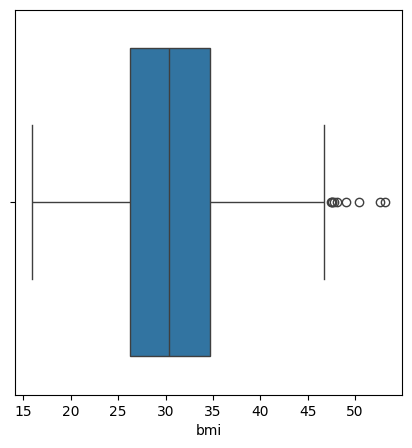

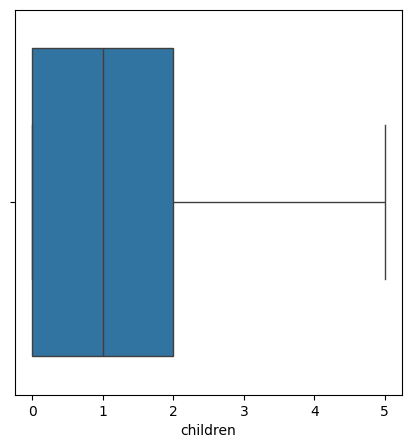

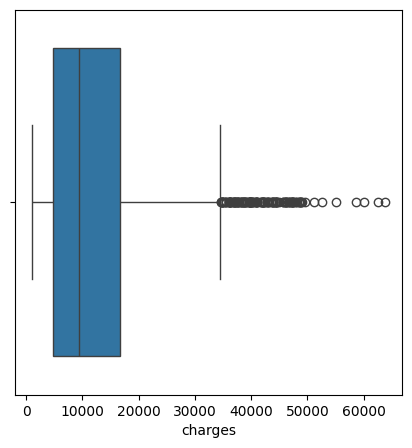

In [15]:
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(x=df[col])
  plt.show()

<Axes: >

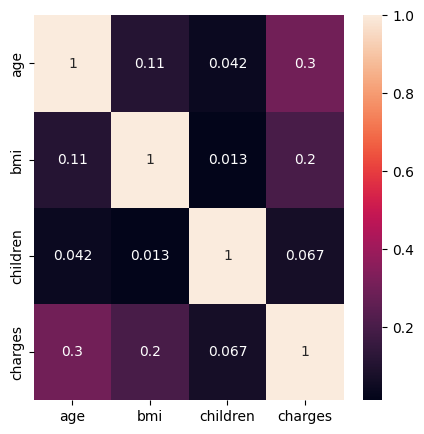

In [16]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Data Cleaning and Preprocessing**

In [17]:
df_cleaned=df.copy()

In [18]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df_cleaned.shape

(1337, 7)

In [20]:
df_cleaned.duplicated().sum()

np.int64(0)

In [21]:
df_cleaned.drop_duplicates(inplace=True)

In [22]:
df_cleaned.isnull().sum(

)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [27]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [30]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [31]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [32]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [34]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [35]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [36]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [37]:
df_cleaned['region'].value_counts()


,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [38]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [39]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [40]:
df_cleaned=df_cleaned .astype(int)

In [41]:
df_cleaned.dtypes

,0
age,int64
sex,int64
bmi,int64
children,int64
smoker,int64
charges,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64


In [42]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


**Feature Engineering and Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

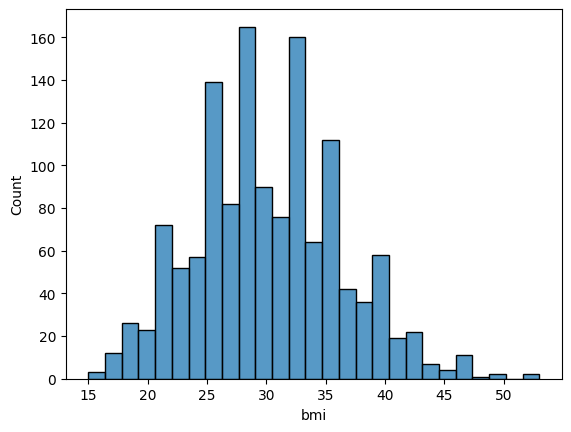

In [43]:
sns.histplot(df_cleaned['bmi'])

In [44]:
df_cleaned['bmi category']=pd.cut(df_cleaned['bmi'],bins=[0,18.5,24.9,29.9,float('inf')],
                                  labels=['underweight','healthy','overweight','obese'])

In [45]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,healthy
4,32,0,28,0,0,3866,1,0,0,overweight


In [46]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi category'],drop_first=True)

In [47]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_healthy,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


**Feature Scaling**

In [48]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [49]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_healthy,bmi category_overweight,bmi category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False


**Feature Extraction**

In [56]:
from scipy.stats import pearsonr
selected_features=['age','children','bmi','smoker','region_northwest','region_southeast','region_southwest',
                   'bmi category_overweight','bmi category_obese']
corelations={
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features

}
corelation_df=pd.DataFrame(list(corelations.items()),columns=['feature','Pearson corelation'])
corelation_df.sort_values(by='Pearson corelation',ascending=False)

,feature,Pearson corelation
3,smoker,0.787234
0,age,0.298309
8,bmi category_obese,0.200348
2,bmi,0.196236
5,region_southeast,0.073577
1,children,0.067390
4,region_northwest,-0.038695
6,region_southwest,-0.043637
7,bmi category_overweight,-0.120601


In [57]:
categorical_features=['children','smoker','age','bmi category_obese', 'region_northwest','region_southwest','	bmi category_overweight']

In [82]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Clean dataframe column names
df_cleaned.columns = df_cleaned.columns.str.replace('\t', '', regex=True).str.strip()

# Clean categorical feature names
categorical_features = [col.strip().replace('\t', '') for col in categorical_features]

# Create bins
df_cleaned["charges_bin"] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_results = {}

for col in categorical_features:

    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])

    chi2_stat, p, _, _ = chi2_contingency(contingency)

    if p < alpha:
        decision = "Reject Null (Keep Feature)"
    else:
        decision = "Accept Null (Drop Feature)"

    chi2_results[col] = {
        'chi2': chi2_stat,
        'p': p,
        'decision': decision
    }

chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df = chi2_results_df.sort_values(by='p')

chi2_results_df

,chi2,p,decision
age,1509.13025,0.0,Reject Null (Keep Feature)
smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
bmi category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi category_overweight,4.25149,0.235557,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


**Final Data Frame**

In [85]:
final_df=df_cleaned[[
    'age',
    'children',
    'bmi',
    'smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi category_obese',
    'bmi category_overweight',
    'charges'
]]

In [86]:
final_df

,age,children,bmi,smoker,region_northwest,region_southeast,region_southwest,bmi category_obese,bmi category_overweight,charges
0,-1.440418,-0.909234,-0.517949,1,0,0,1,False,True,16884
1,-1.511647,-0.079442,0.462463,0,0,1,0,True,False,1725
2,-0.799350,1.580143,0.462463,0,0,1,0,True,False,4449
3,-0.443201,-0.909234,-1.334960,0,1,0,0,False,False,21984
4,-0.514431,-0.909234,-0.354547,0,1,0,0,False,True,3866
...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,1.580143,-0.027743,0,1,0,0,True,False,10600
1334,-1.511647,-0.909234,0.135659,0,0,0,0,True,False,2205
1335,-1.511647,-0.909234,0.952670,0,0,1,0,True,False,1629
1336,-1.297958,-0.909234,-0.844753,0,0,0,1,False,True,2007


**Now on the data the EDA has been done and also the feature Selection also now we give the data to train the model**